In [ ]:
#TODO
# SAM, MedSAM(fine-tuned decoder), SAMMed2D(fine-tuned all) results over 51 datasets

#### How can we fine tune SAM effectively with the least data?  

1. Will different selection query give us different  results?    
constraint:  
 dataset size:51 (40 train; 11 test)  
 epochs: 1000 for add one sample 
 fixed random seed  
 model: SAM  
 checkpoint: b  
 fine-tuning structure: mask decoder  

* baseline: random selection from 40 dataset
* entropy with dropout 
* entropy with dropout + artifacts
* encoder of SAM + clustering  



- Plot: Accuracy on the 11 test set as a function of number of selected samples (training)
- ID of selected samples for each iteration

In [1]:
import datasets.path as path
# import nibabel as nib
from glob import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import monai
from tqdm import tqdm
import json
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
import matplotlib.pyplot as plt
import wandb
from utils import NpzDataset, save_preds_nii
from metrics import compute_dice_coefficient
from strategy import random_sampling
from eval import infer, log_image_table
import SimpleITK as sitk


In [2]:
# training and sampling dataset path prefix
prefix = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/datasets/RAINE_organ_51'
task = 'MRI_LeftKidney'
training_pool_path = os.path.join(prefix, task, 'train')
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 1

#SAM MODEL TYPE 
sam_model_type = 'vit_b'
# SAM checkpoint
checkpoint = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# sample strategy
strategy = 'random'
# active learning fine tunning checkpoint
base_model = 'SAM'
save_path_ckp = os.path.join('./checkpoints/', base_model + '_' + task + '_' + strategy)
os.makedirs(save_path_ckp, exist_ok=True)
# sampling dataset path
sampling_datapath = os.path.join(prefix, task, base_model+'_sampling')
os.makedirs(sampling_datapath, exist_ok=True)

In [3]:
training_pool = glob(os.path.join(training_pool_path, '*.npz'))
sample_pool = []
# num_epochs = 150
# batch_size = 16 # make sure batch size is smaller than sample slices
seed = 2020
batch_size = 1
num_epochs = 10
losses = []
best_loss = 1e10
sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)

# Set up the optimizer, hyperparameter tuning will improve performance here
optimizer = torch.optim.Adam(sam_model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)
seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

save_path_ckp_seed_epoch = os.path.join(save_path_ckp, f'seed{seed}', f'epochs{num_epochs}')
os.makedirs(save_path_ckp_seed_epoch, exist_ok=True)

# wandb
# wandb.init(
#     # Set the project where this run will be logged
#     project="SAM-Activelearning", 
#     group="random",
#     name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
#     config = {
#         "task": task,
#         'label_id': label_id,
#         'base_model': base_model,
#         "model": sam_model_type,
#         "strategy": strategy,
#         "num_epochs": num_epochs
#     }
# )


In [4]:
from skimage.transform import rotate

def tta_transforms(imgs, gts):

    # perform a 45 degree rotation
    img_rotated_45 = [rotate(imgs[i], 45, order=3, preserve_range=True).astype(np.uint8)
                        for i in range(imgs.shape[0])]
    img_rotated_45 = np.array(img_rotated_45)
    # print('image rotated 45 degree intensity: ', np.min(img_rotated_45), np.max(img_rotated_45))
    gt_rotated_45 = [rotate(gts[i], 45, order=3, preserve_range=True)
                        for i in range(gts.shape[0])]
    gt_rotated_45 = np.array(gt_rotated_45)

    img_rotated_90 = [rotate(imgs[i], 90, order=3, preserve_range=True).astype(np.uint8)
                        for i in range(imgs.shape[0])]
    img_rotated_90 = np.array(img_rotated_90)
    # print('image rotated 90 degree intensity: ', np.min(img_rotated_90), np.max(img_rotated_90))
    gt_rotated_90 = [rotate(gts[i], 90, order=3, preserve_range=True) for i in range(gts.shape[0])]
    gt_rotated_90 = np.array(gt_rotated_90)

    img_rotated_135 = [rotate(imgs[i], 135, order=3, preserve_range=True).astype(np.uint8)
                       for i in range(imgs.shape[0])]
    img_rotated_135 = np.array(img_rotated_135)
    # print('image rotated 135 degree intensity: ', np.min(img_rotated_135), np.max(img_rotated_135))
    gt_rotated_135 = [rotate(gts[i], 135, order=3, preserve_range=True) for i in range(gts.shape[0])]
    gt_rotated_135 = np.array(gt_rotated_135)

    img_flip_horizontal = np.flip(imgs, axis=2)
    # print('image flip horizontal intensity: ', np.min(img_flip_horizontal), np.max(img_flip_horizontal))    
    gt_flip_horizontal = np.flip(gts, axis=2)

    img_flip_vertical = np.flip(imgs, axis=1)
    # print('image flip vertical intensity: ', np.min(img_flip_vertical), np.max(img_flip_vertical))
    gt_flip_vertical = np.flip(gts, axis=1)

    transformed_img = [img_rotated_45, img_rotated_90, img_rotated_135, img_flip_horizontal, img_flip_vertical]
    transformed_gt = [gt_rotated_45, gt_rotated_90, gt_rotated_135, gt_flip_horizontal, gt_flip_vertical]
    return transformed_img, transformed_gt

In [5]:
training_pool = glob(os.path.join(training_pool_path, '*.npz'))
save_path_tr = os.path.join(prefix, task, 'train_tta')
os.makedirs(save_path_tr, exist_ok=True)
sam_lk = sam_model_registry['vit_b'](checkpoint='checkpoints/SAM/sam_vit_b_01ec64.pth').to(device)

In [6]:
# pre-compute embeddings for TTA

# predictor = SamPredictor(sam_lk)
# transformed_preds = []
for t in tqdm(training_pool):
    imgs = np.load(t)['imgs']   # (S, H, W, 3)
    # print('original intensity: ', np.min(imgs), np.max(imgs))
    gts = np.load(t)['gts']     # (S, H, W)
    # print(imgs.shape, type(imgs))
    
    transformed_img, transformed_gt = tta_transforms(imgs, gts)
    break
    
    # transformed_emdeddings = []
    # for img in transformed_img:
    #     # preds = []
    #     for i in range(img.shape[0]):
    #         img_embeddings = []
    #         sam_transform = ResizeLongestSide(sam_lk.image_encoder.img_size)
    #         # print(img[i].shape)
    #         # break
    #         resize_img = sam_transform.apply_image(img[i])
    #         resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
    #         # model input: (1, 3, 1024, 1024)
    #         input_image = sam_lk.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
    #         assert input_image.shape == (1, 3, sam_lk.image_encoder.img_size, sam_lk.image_encoder.img_size), 'input image should be resized to 1024*1024'
    #         with torch.no_grad():
    #             embedding = sam_lk.image_encoder(input_image)
    #             img_embeddings.append(embedding.cpu().numpy()[0])
    #     img_embeddings = np.stack(img_embeddings, axis=0)
    #     transformed_emdeddings.append(img_embeddings)
    # transformed_emdeddings = np.stack(transformed_emdeddings, axis=0)
    # print(transformed_emdeddings.shape)
    # id = os.path.basename(t).split('.')[0]
    # np.savez_compressed(os.path.join(save_path_tr, f'{id}_tta.npz'), transformed_emdeddings=transformed_emdeddings)
    
    

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:01<?, ?it/s]


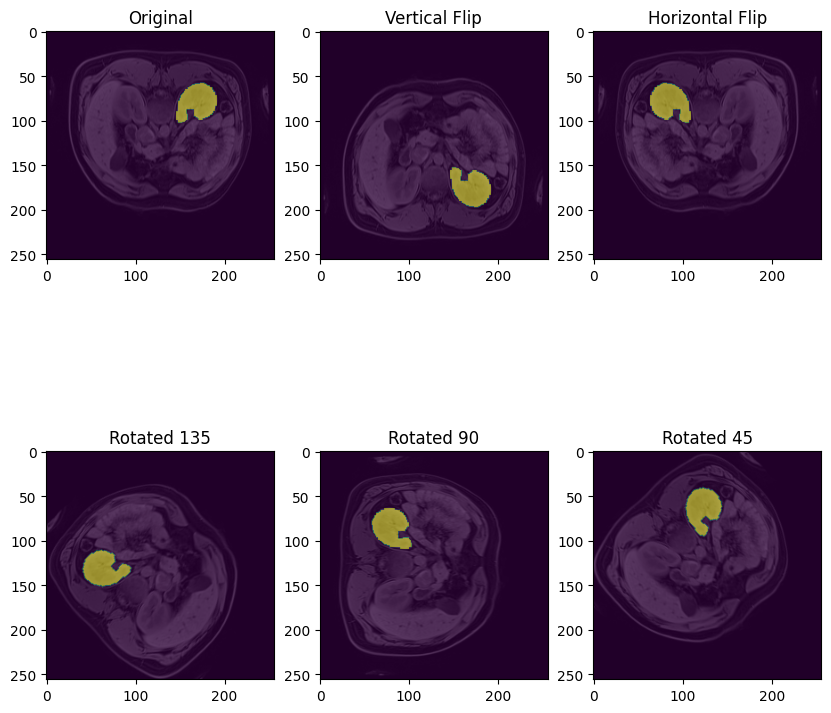

In [7]:
# plot imgs and gts after TTA
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
index = 22
ax[0,0].imshow(imgs[index])
ax[0,0].imshow(gts[index], alpha=0.5)
ax[0,0].title.set_text('Original')

ax[0,1].imshow(transformed_img[4][index])
ax[0,1].imshow(transformed_gt[4][index], alpha=0.5)
ax[0,1].title.set_text('Vertical Flip')

ax[0,2].imshow(transformed_img[3][index])
ax[0,2].imshow(transformed_gt[3][index], alpha=0.5)
ax[0,2].title.set_text('Horizontal Flip')

ax[1,0].imshow(transformed_img[2][index])
ax[1,0].imshow(transformed_gt[2][index], alpha=0.5)
ax[1,0].title.set_text('Rotated 135')

ax[1,1].imshow(transformed_img[1][index])
ax[1,1].imshow(transformed_gt[1][index], alpha=0.5)
ax[1,1].title.set_text('Rotated 90')

ax[1,2].imshow(transformed_img[0][index])
ax[1,2].imshow(transformed_gt[0][index], alpha=0.5)
ax[1,2].title.set_text('Rotated 45')
plt.show()

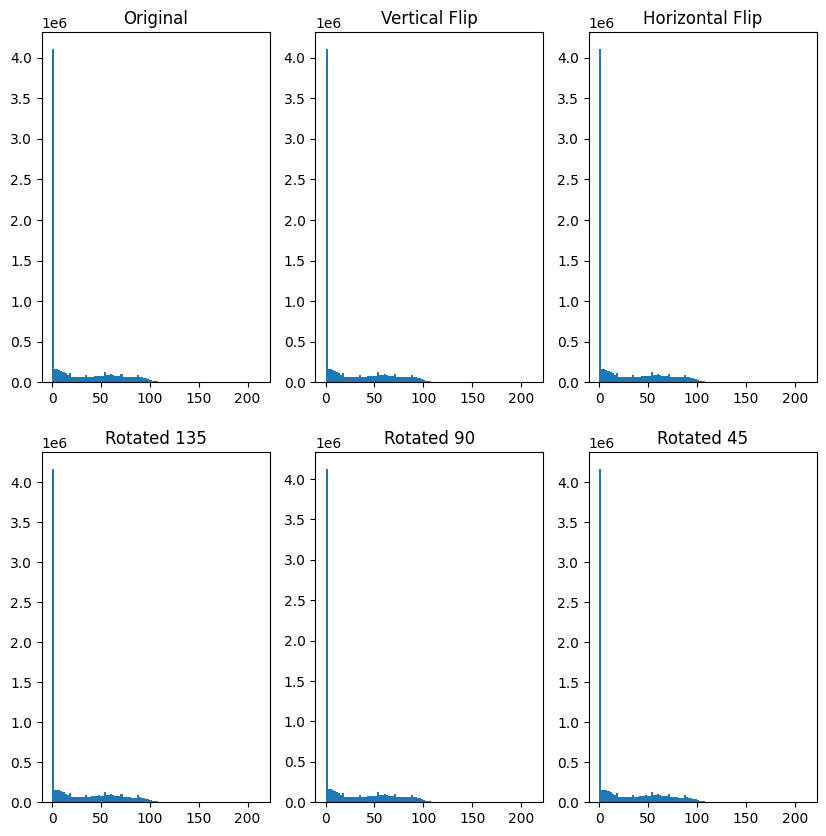

In [8]:
# intensity histogram for original image and transformed image
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
index = 22
ax[0,0].hist(imgs.flatten(), bins=100)
ax[0,0].title.set_text('Original')
# ax[0,0].set_ylim([0, 1e6])

ax[0,1].hist(transformed_img[4].flatten(), bins=100)
ax[0,1].title.set_text('Vertical Flip')
# ax[0,1].set_ylim([0, 1e6])

ax[0,2].hist(transformed_img[3].flatten(), bins=100)
ax[0,2].title.set_text('Horizontal Flip')
# ax[0,2].set_ylim([0, 1e6])

ax[1,0].hist(transformed_img[2].flatten(), bins=100)
ax[1,0].title.set_text('Rotated 135')

ax[1,1].hist(transformed_img[1].flatten(), bins=100)
ax[1,1].title.set_text('Rotated 90')

ax[1,2].hist(transformed_img[0].flatten(), bins=100)
ax[1,2].title.set_text('Rotated 45')

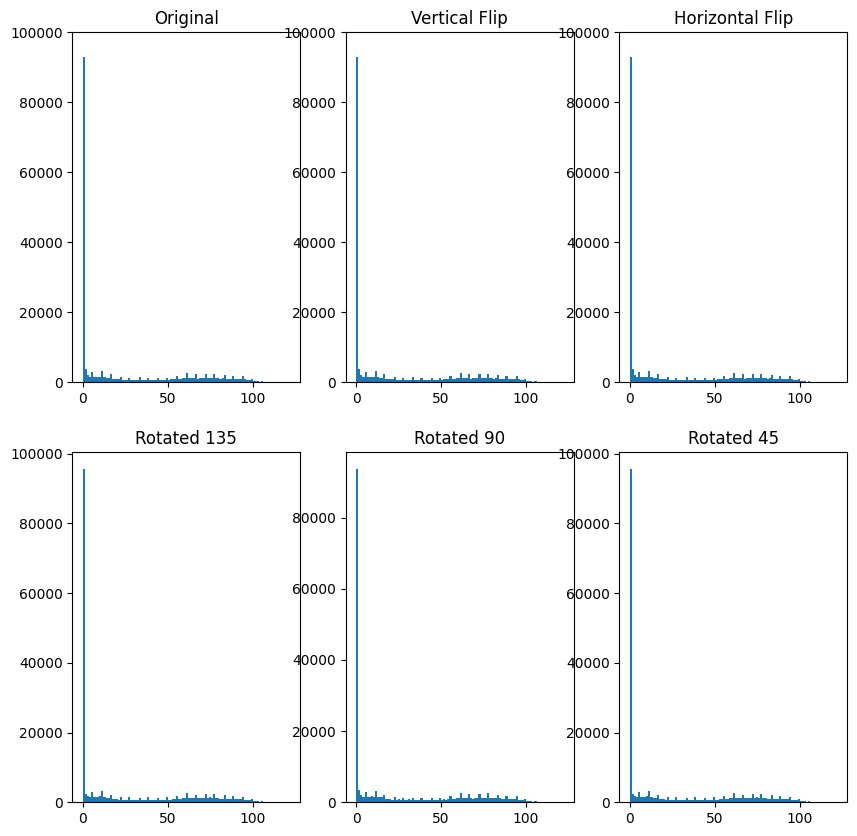

In [9]:
# intensity histogram for original image and transformed image on slice 22
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
index = 22
ax[0,0].hist(imgs[index].flatten(), bins=100)
ax[0,0].title.set_text('Original')
ax[0,0].set_ylim([0, 100000])

ax[0,1].hist(transformed_img[4][index].flatten(), bins=100)
ax[0,1].title.set_text('Vertical Flip')
ax[0,1].set_ylim([0, 100000])

ax[0,2].hist(transformed_img[3][index].flatten(), bins=100)
ax[0,2].title.set_text('Horizontal Flip')
ax[0,2].set_ylim([0, 100000])

ax[1,0].hist(transformed_img[2][index].flatten(), bins=100)
ax[1,0].title.set_text('Rotated 135')

ax[1,1].hist(transformed_img[1][index].flatten(), bins=100)
ax[1,1].title.set_text('Rotated 90')

ax[1,2].hist(transformed_img[0][index].flatten(), bins=100)
ax[1,2].title.set_text('Rotated 45')

plt.show()

In [13]:
# Check prediction after tta
original_sam = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/SAM/sam_vit_b_01ec64.pth'
original_medsam = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/MedSAM/medsam_20230423_vit_b_0.0.1.pth'
sam_random_40 = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/SAM_MRI_LeftKidney_random/seed2023/epochs100/SAM_vit_b_40_latest.pth'
medsam_random_40 = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/MedSAM_MRI_LeftKidney_random/seed2023/epochs100/MedSAM_vit_b_40_latest.pth'
dynunet_random_40 = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/DynUNet_MRI_LeftKidney_random/seed2023/epochs100/DynUNet_vit_b_40_latest.pth'

In [15]:
# sam related model prediction
sam_lk = sam_model_registry['vit_b'](checkpoint=sam_random_40).to(device)
predictor = SamPredictor(sam_lk)
transformed_preds = []  # 1m30s
for img in transformed_img:
    preds = []
    for i in range(img.shape[0]): # infer for each slice
        predictor.set_image(img[i])
        input_box = np.array([0, 0, img[index].shape[0], img[index].shape[1]]) # whole image as bbox
        masks, _, _ = predictor.predict(
            point_coords=None,
            point_labels=None,
            box=input_box[None, :],
            multimask_output=False,
        )
        preds.append(masks[0])
    preds = np.array(preds)
    transformed_preds.append(preds)

In [ ]:
# TODO: dynunet model prediction

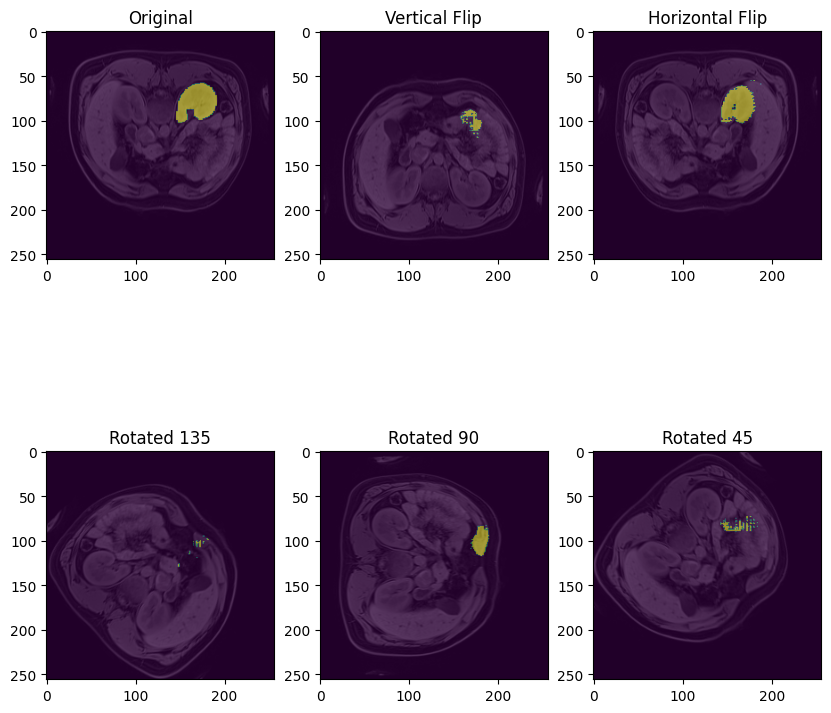

In [16]:
# plot predictions after tta
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
index = 22
ax[0,0].imshow(imgs[index])
ax[0,0].imshow(gts[index], alpha=0.5)
ax[0,0].title.set_text('Original')

ax[0,1].imshow(transformed_img[4][index], cmap='gray')
ax[0,1].imshow(transformed_preds[4][index], alpha=0.5)
ax[0,1].title.set_text('Vertical Flip')

ax[0,2].imshow(transformed_img[3][index], cmap='gray')
ax[0,2].imshow(transformed_preds[3][index], alpha=0.5)
ax[0,2].title.set_text('Horizontal Flip')

ax[1,0].imshow(transformed_img[2][index], cmap='gray')
ax[1,0].imshow(transformed_preds[2][index], alpha=0.5)
ax[1,0].title.set_text('Rotated 135')

ax[1,1].imshow(transformed_img[1][index], cmap='gray')
ax[1,1].imshow(transformed_preds[1][index], alpha=0.5)
ax[1,1].title.set_text('Rotated 90')

ax[1,2].imshow(transformed_img[0][index], cmap='gray')
ax[1,2].imshow(transformed_preds[0][index], alpha=0.5)
ax[1,2].title.set_text('Rotated 45')

plt.show()


In [11]:
transformed_preds_array = np.array(transformed_preds)
print(transformed_preds_array.shape)
mode = np.array(torch.mode(torch.Tensor(transformed_preds_array.astype(np.int64)), dim=0).values)
mean: np.ndarray = np.mean(transformed_preds_array, axis=0) 
std: np.ndarray = np.std(transformed_preds_array, axis=0) 
vvc: float = (np.std(transformed_preds_array) / np.mean(transformed_preds_array)).item()
print('mode:', mode, 'mean:', mean, 'std:', std, 'vvc:', vvc)

(5, 41, 256, 256)
mode: [[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ..

In [14]:
std.shape

(41, 256, 256)

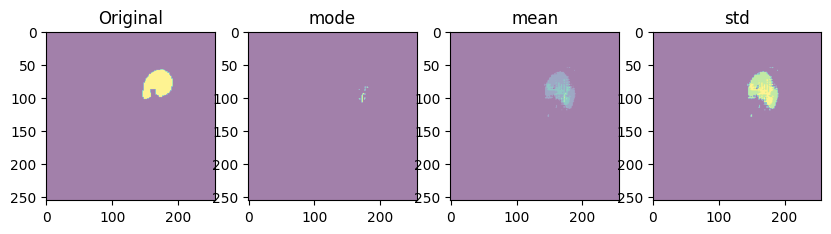

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(10, 10))
index = 22
# ax[0].imshow(imgs[index])
ax[0].imshow(gts[index], alpha=0.5)
ax[0].title.set_text('Original')

# ax[1].imshow(transformed_img[4][index])
ax[1].imshow(mode[index], alpha=0.5)
ax[1].title.set_text('mode')

# ax[2].imshow(transformed_img[3][index])
ax[2].imshow(mean[index], alpha=0.5)
ax[2].title.set_text('mean')

# ax[3].imshow(transformed_img[2][index])
ax[3].imshow(std[index], alpha=0.5)
ax[3].title.set_text('std')

plt.show()

In [63]:
class TTADataset(Dataset):
    def __init__(self, sample_pool_path):
        self.npz_files = sorted(sample_pool_path) 
        self.npz_data = [np.load(f) for f in self.npz_files]
        self.img_embeddings = np.vstack([d['transformed_emdeddings'] for d in self.npz_data])
        # print(f"{self.img_embeddings.shape=}")  # (5, 1, 256, 64, 64)
    
    def __len__(self):
        return self.img_embeddings.shape[1]

    def __getitem__(self, index):
        img_embed = self.img_embeddings[:,index,:,:,:]
        # convert img embedding, mask, bounding box to torch tensor
        return torch.tensor(img_embed).float()

In [86]:
def tta_sampling(training_pool, sample_pool, tta_pool, ckp_path, sam_model_type, device):
    """TTA sampling
    Args:
        training_pool: list of npz files in training pool
        sample_pool: list of npz files in sample pool
        model: model for inference
        device: device to run model
    Return:
        sample_pool: list of npz files in sample pool
        training_pool: list of npz files in training pool
    """
    np.random.seed(2023)
    tta_score = {}
    for i, (tta_path, train_path)  in enumerate(zip(sorted(tta_pool), sorted(training_pool))):
        id = os.path.basename(tta_path).split('_')[0]
        imgs = np.load(train_path)['imgs']   # (S, H, W, 3)
        # transformed_emdeddings = np.load(tta_path)['transformed_emdeddings'] # (5, 1, 256, 64, 64)
        # for embedding in transformed_emdeddings:
        # load all samples in training pool
        dataset = TTADataset([tta_path])
        batch_size = len(dataset)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
        for embeddings in dataloader:
            transformed_preds = []
            for embed in embeddings:
                preds, _ = infer(imgs, embed, ckp_path, sam_model_type, device)
                # print(preds.shape)
                transformed_preds.append(preds)
        transformed_preds_array = np.array(transformed_preds)
        # compute vvc
        mode = np.array(torch.mode(torch.Tensor(transformed_preds_array.astype(np.int64)), dim=0).values)
        mean: np.ndarray = np.mean(preds) 
        std: np.ndarray = np.std(preds) 
        vvc: float = (np.std(preds) / np.mean(preds)).item()
        tta_score[id] = vvc
        
    # sort tta score
    next_id = max(tta_score, key=tta_score.get)

    # select the sample with highest vvc
    next_sample = os.path.join(os.path.commonpath(training_pool), next_id+'.FatImaging_W.npz')
    sample_pool.append(next_sample)
    # print(os.path.join('./datasets/RAINE_organ_51/MRI_LeftKidney/train_tta/', next_id+'_tta.npz'))
    tta_pool.remove(os.path.join('./datasets/RAINE_organ_51/MRI_LeftKidney/train_tta/', f'{next_id}_tta.npz'))

    return sample_pool, tta_pool, tta_score

In [46]:
sorted(training_pool)[0]

'./datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-10010.FatImaging_W.npz'

In [52]:
os.path.commonpath(training_pool)

'datasets/RAINE_organ_51/MRI_LeftKidney/train'

In [67]:
sorted(tta_pool)[0]

'./datasets/RAINE_organ_51/MRI_LeftKidney/train_tta/sub-10010_tta.npz'

In [47]:

os.path.basename(sorted(tta_pool)[0]).split('_')[0]

'sub-10010'

In [87]:
tta_pool_path = os.path.join(prefix, task, 'train_tta')
tta_pool = glob(os.path.join(tta_pool_path, '*.npz'))
for i in range(len(training_pool)):
    
    sample_pool, tta_pool, tta_score = tta_sampling(training_pool, sample_pool, tta_pool, checkpoint, sam_model_type, device)
    print(sample_pool)
    print(tta_score)
    break
    # num_samples = len(sample_pool)
    # if num_samples > 2 and num_samples <= 5:
    #     batch_size = 32
    # elif num_samples > 5:
    #     batch_size = 64
    
    # print('Number of samples: ', num_samples, '\tBatch size: ', batch_size)
    # sample_dataset = NpzDataset(sample_pool)
    # sample_dataloader = DataLoader(sample_dataset, batch_size=batch_size, shuffle=True)
    # for epoch in range(num_epochs):
    #     epoch_loss = 0
    #     for step, (image_embedding, gt2D, boxes) in enumerate(tqdm(sample_dataloader)):
    #         # img_embed: (B, 256, 64, 64), gt2D: (B, 1, 256, 256), bboxes: (B, 4)
    #         # print(f"{image_embedding.shape=}, {gt2D.shape=}, {boxes.shape=}")
    #         with torch.no_grad():
    #             box_np = boxes.numpy() # [0, 0, 256, 256]
    #             sam_trans = ResizeLongestSide(sam_model.image_encoder.img_size)
    #             box = sam_trans.apply_boxes(box_np, (gt2D.shape[-2], gt2D.shape[-1]))
    #             box_torch = torch.as_tensor(box, dtype=torch.float, device=device)
    #             if len(box_torch.shape) == 2:
    #                 box_torch = box_torch[:, None, :] # (B, 1, 4)
    #             # get prompt embeddings 
    #             sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
    #                 points=None,
    #                 boxes=box_torch,
    #                 masks=None,
    #             )
    #         # predicted masks
    #         # print(f"{image_embedding.shape=}, {sparse_embeddings.shape=}, {dense_embeddings.shape=}")
    #         mask_predictions, _ = sam_model.mask_decoder(
    #             image_embeddings=image_embedding.to(device), # (B, 256, 64, 64)
    #             image_pe=sam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
    #             sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
    #             dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
    #             multimask_output=False,
    #         )

    #         loss = seg_loss(mask_predictions, gt2D.to(device))
    #         optimizer.zero_grad()
    #         loss.backward()
    #         optimizer.step()
    #         epoch_loss += loss.item()
    #     epoch_loss /= step
    #     losses.append(epoch_loss)
    #     print(f'EPOCH: {epoch}, Loss: {epoch_loss}')
    #     # if args.wandb:
    #     #     wandb.log({f"Train/loss of {num_samples} num sample": epoch_loss})
    #     # save the latest model checkpoint
    #     torch.save(sam_model.state_dict(), os.path.join(save_path_ckp_epoch, f'{base_model}_{sam_model_type}_{num_samples:02d}_latest.pth'))
    #     # save the best model
    #     if epoch_loss < best_loss:
    #         best_loss = epoch_loss
    #         torch.save(sam_model.state_dict(), os.path.join(save_path_ckp_epoch, f'{base_model}_{sam_model_type}_{num_samples:02d}_best.pth'))

 # './datasets/RAINE_organ_51/MRI_LeftKidney/train_tta/sub-10010_tta.npz'

['datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz', 'datasets/RAINE_organ_51/MRI_LeftKidney/train/sub-23400.FatImaging_W.npz']
{'sub-10010': 0.9550614065471904, 'sub-10020': 0.8872882634908654, 'sub-10050': 1.0093515855097244, 'sub-10150': 0.6361603982479679, 'sub-10170': 0.751019544716532, 'sub-10250': 0.8861407093829387, 'sub-10270': 1.00111145751227, 'sub-10280': 0.85932

In [90]:
max(tta_score, key=tta_score.get)

'sub-23400'

In [ ]:
# !export WANDB_BASE_URL=http://172.17.0.1:8080
# !export WANDB_API_KEY=4aaa2e71cdec13a78a42c6ceac38dd0c7235a131

# wandb.login()

In [ ]:
# eval on test set

num_epochs = 150
ckp_paths = sorted(glob(os.path.join(save_path_ckp, f'epochs{num_epochs}', '*latest.pth')))
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))
dice_test = []

# wandb
wandb.init(
    # Set the project where this run will be logged
    project="SAM-Activelearning", 
    group="random",
    name=f'{base_model}_{sam_model_type}_{task}_{strategy}_epoch{num_epochs}',
    config = {
        "task": task,
        'label_id': label_id,
        'base_model': base_model,
        "model": sam_model_type,
        "strategy": strategy,
        "num_epochs": num_epochs
    }
)
table = wandb.Table(columns=["image", "pred", "gt", 'id', 'dice'])

# eval on test set for each checkpoint
for p in tqdm(ckp_paths):
    avg_dice = []
    for t in tqdm(testing_pool):
        id = os.path.basename(t).split('.')[0]
        imgs = np.load(t)['imgs']

        dataset = NpzDataset([t])
        batch_size = len(dataset)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
        for embeddings, gts, _ in dataloader:
            preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
        gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
        dice = compute_dice_coefficient(gts, preds)
        avg_dice.append(dice)
        if '40' in p:
            preds_int = preds * 1 # convert boolean to int
            log_image_table(imgs, preds_int, gts, id, dice, table)
    dice_test.append(np.mean(avg_dice))
    wandb.log({f"Eval/Dice {strategy} epoch{num_epochs}": np.mean(avg_dice)}, commit=True)
wandb.log({f"predictions_table {strategy} epoch{num_epochs}":table}, commit=True)
wandb.finish()
    

In [ ]:
plt.plot(dice_test)
plt.xlabel('Number of samples')
plt.ylabel('Dice coefficient')
plt.title(f'{base_model} {task} {strategy} sampling')
plt.show()
plt.savefig(os.path.join('figures/eval', f'{base_model}_{task}_{strategy}_epochs{num_epochs}_sampling.png'))
plt.close()

In [ ]:
# testing whole image bbox for original SAM
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))

p = 'checkpoints/SAM/sam_vit_b_01ec64.pth'
for t in tqdm(testing_pool):
    id = os.path.basename(t).split('.')[0]
    imgs = np.load(t)['imgs']

    dataset = NpzDataset([t])
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, _ in dataloader:
        preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
    # print(preds.shape, type(preds))

    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    # print(gts.shape, type(gts))  
    dice = compute_dice_coefficient(gts, preds)
    avg_dice.append(dice)

In [ ]:
# testing whole image bbox for MedSAM
testing_pool_path = os.path.join(prefix, task, 'test')
testing_pool = glob(os.path.join(testing_pool_path, '*.npz'))

p = 'checkpoints/MedSAM/medsam_20230423_vit_b_0.0.1.pth'
for t in tqdm(testing_pool):
    id = os.path.basename(t).split('.')[0]
    imgs = np.load(t)['imgs']

    dataset = NpzDataset([t])
    batch_size = len(dataset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # make sure batch size is larger than sample slices
    for embeddings, gts, _ in dataloader:
        preds, _ = infer(imgs, embeddings, p, sam_model_type, device)
    # print(preds.shape, type(preds))

    gts = gts[:, 0, :, :].numpy() # convert tensor to numpy (B, H, W)
    # print(gts.shape, type(gts))  
    dice = compute_dice_coefficient(gts, preds)
    avg_dice.append(dice)
print(avg_dice)
print(np.mean(avg_dice))

In [18]:
dice_seed2020 = np.load('results/dice/epochs100/random_MRI_LeftKidney_SAM_vit_b_epochs100_seed2020_test_dice.npy')
dice_seed2021 = np.load('results/dice/epochs100/random_MRI_LeftKidney_SAM_vit_b_epochs100_seed2021_test_dice.npy')
dice_seed2022 = np.load('results/dice/epochs100/random_MRI_LeftKidney_SAM_vit_b_epochs100_seed2022_test_dice.npy')
dice_seed2023 = np.load('results/dice/epochs100/random_MRI_LeftKidney_SAM_vit_b_epochs100_seed2023_test_dice.npy')
dice_seed2024 = np.load('results/dice/epochs100/random_MRI_LeftKidney_SAM_vit_b_epochs100_seed2024_test_dice.npy')



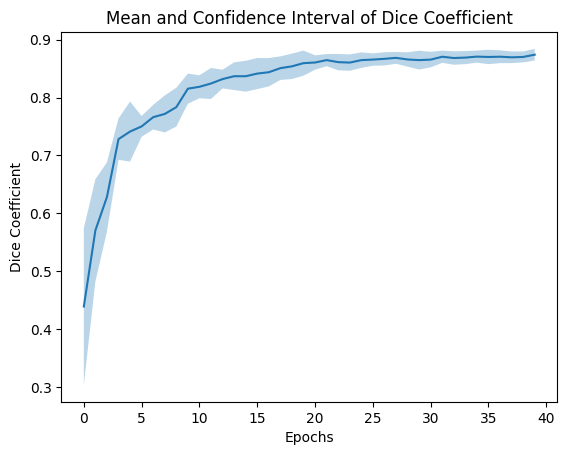

In [20]:
# Calculate the mean and confidence interval
mean = np.mean([dice_seed2020, dice_seed2021, dice_seed2022, dice_seed2023, dice_seed2024], axis=0)
confidence_interval = 1.96 * np.std([dice_seed2020, dice_seed2021, dice_seed2022, dice_seed2023, dice_seed2024], axis=0) / np.sqrt(5)

# Plot the mean and confidence interval
plt.plot(mean, label='Mean')
plt.fill_between(range(len(mean)), mean - confidence_interval, mean + confidence_interval, alpha=0.3, label='Confidence Interval')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Mean and Confidence Interval of Dice Coefficient')
# plt.legend()
plt.show()


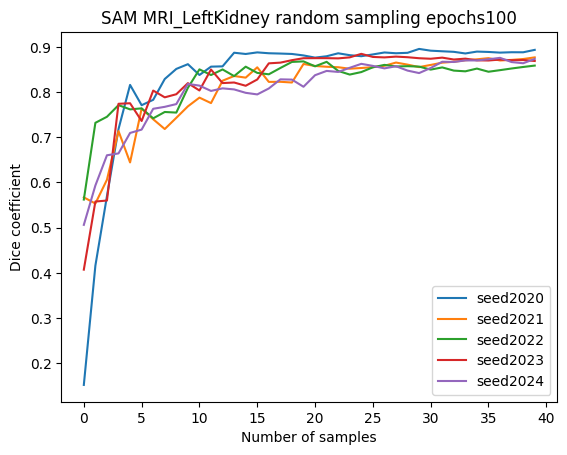

In [19]:
plt.plot(dice_seed2020, label='seed2020')
plt.plot(dice_seed2021, label='seed2021')
plt.plot(dice_seed2022, label='seed2022')
plt.plot(dice_seed2023, label='seed2023')
plt.plot(dice_seed2024, label='seed2024')
plt.xlabel('Number of samples')
plt.ylabel('Dice coefficient')
plt.title(f'{base_model} {task} {strategy} sampling epochs100')
plt.legend()
plt.show()